In [ ]:
import pandas as pd
import glob

derbys = "Derby Statistics*.csv"
all_derbys = glob.glob(derbys)

# read and open the files and put into a df
df_derby = [pd.read_csv(file) for file in all_derbys]

# make them all into one
if df_derby:
    combined_df = pd.concat(df_derby, ignore_index=True)
    print(f"Loaded {len(all_derbys)} files.")
else:
    print("No files found matching the pattern.")


Loaded 11 files.


In [ ]:
import pandas as pd
import glob
import re

derbys = "Derby Statistics*.csv"
all_derbys = glob.glob(derbys)

dfs = []

for file in all_derbys:
    try:
        df = pd.read_csv(file)

        # Extract the SECOND year (after the dash)
        match = re.search(r"-\s*(\d{4})", file)
        if match:
            df["Year"] = int(match.group(1))
        else:
            raise ValueError(f"Year not found in filename: {file}")

        dfs.append(df)

    except Exception as e:
        print(f"Skipping {file}: {e}")

df_derby = pd.concat(dfs, ignore_index=True)


In [ ]:
df_derby

,Post Position,Horse,Morning Line,Derby Points,Trainer,Jockey,Last Beyer,Year,Unnamed: 3,Last Beyer
0,1,Firenze Fire,50-1,39,Servis,Lopez,81.0,2018,NaN,NaN
1,2,Free Drop Billy,30-1,44,Romans,Albarado,89.0,2018,NaN,NaN
2,3,Promises Fulfilled,30-1,52,Romans,Lanerie,47.0,2018,NaN,NaN
3,4,Flameaway,30-1,70,Casse,Lezcano,93.0,2018,NaN,NaN
4,5,Audible,8-1,110,Pletcher,Castellano,99.0,2018,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
226,16,King Fury,20-1,20,McPeek,"Hernandez, Jr.",95.0,2021,NaN,NaN
227,17,Highly Motivated,10-1,50,Brown,Castellano,97.0,2021,NaN,NaN
228,18,Super Stock,30-1,109,Asmussen,"Santana, Jr.",92.0,2021,NaN,NaN
229,19,Soup and Sandwich,30-1,40,Casse,Gaffalione,90.0,2021,NaN,NaN


In [ ]:
df_derby['Last Beyer'] = df_derby['Last Beyer  ']

In [ ]:
#seperate by race split split each race into 3rds, and then 3 datasets of each 3rd

In [ ]:
df_derby = df_derby.drop('Last Beyer  ', axis=1)

In [ ]:
import matplotlib.pyplot as plt

def frac_to_numeric(odds):
    try:
        num, den = str(odds).split("-")
        return float(num) / float(den)
    except:
        return None

df_derby["MorningLineNumeric"] = df_derby["Morning Line"].apply(frac_to_numeric)

In [ ]:
def split_into_thirds(df):
    df = df.sort_values("MorningLineNumeric").copy()

    n = len(df)
    df["Tier"] = "Middle"  # default

    df.iloc[: n // 3, df.columns.get_loc("Tier")] = "Top"
    df.iloc[2 * n // 3 :, df.columns.get_loc("Tier")] = "Bottom"

    return df


In [ ]:
df_derby = (
    df_derby
    .groupby("Year", group_keys=False)
    .apply(split_into_thirds)
)

In [ ]:
top = df_derby[df_derby["Tier"] == "Top"]
middle = df_derby[df_derby["Tier"] == "Middle"]
bottom = df_derby[df_derby["Tier"] == "Bottom"]


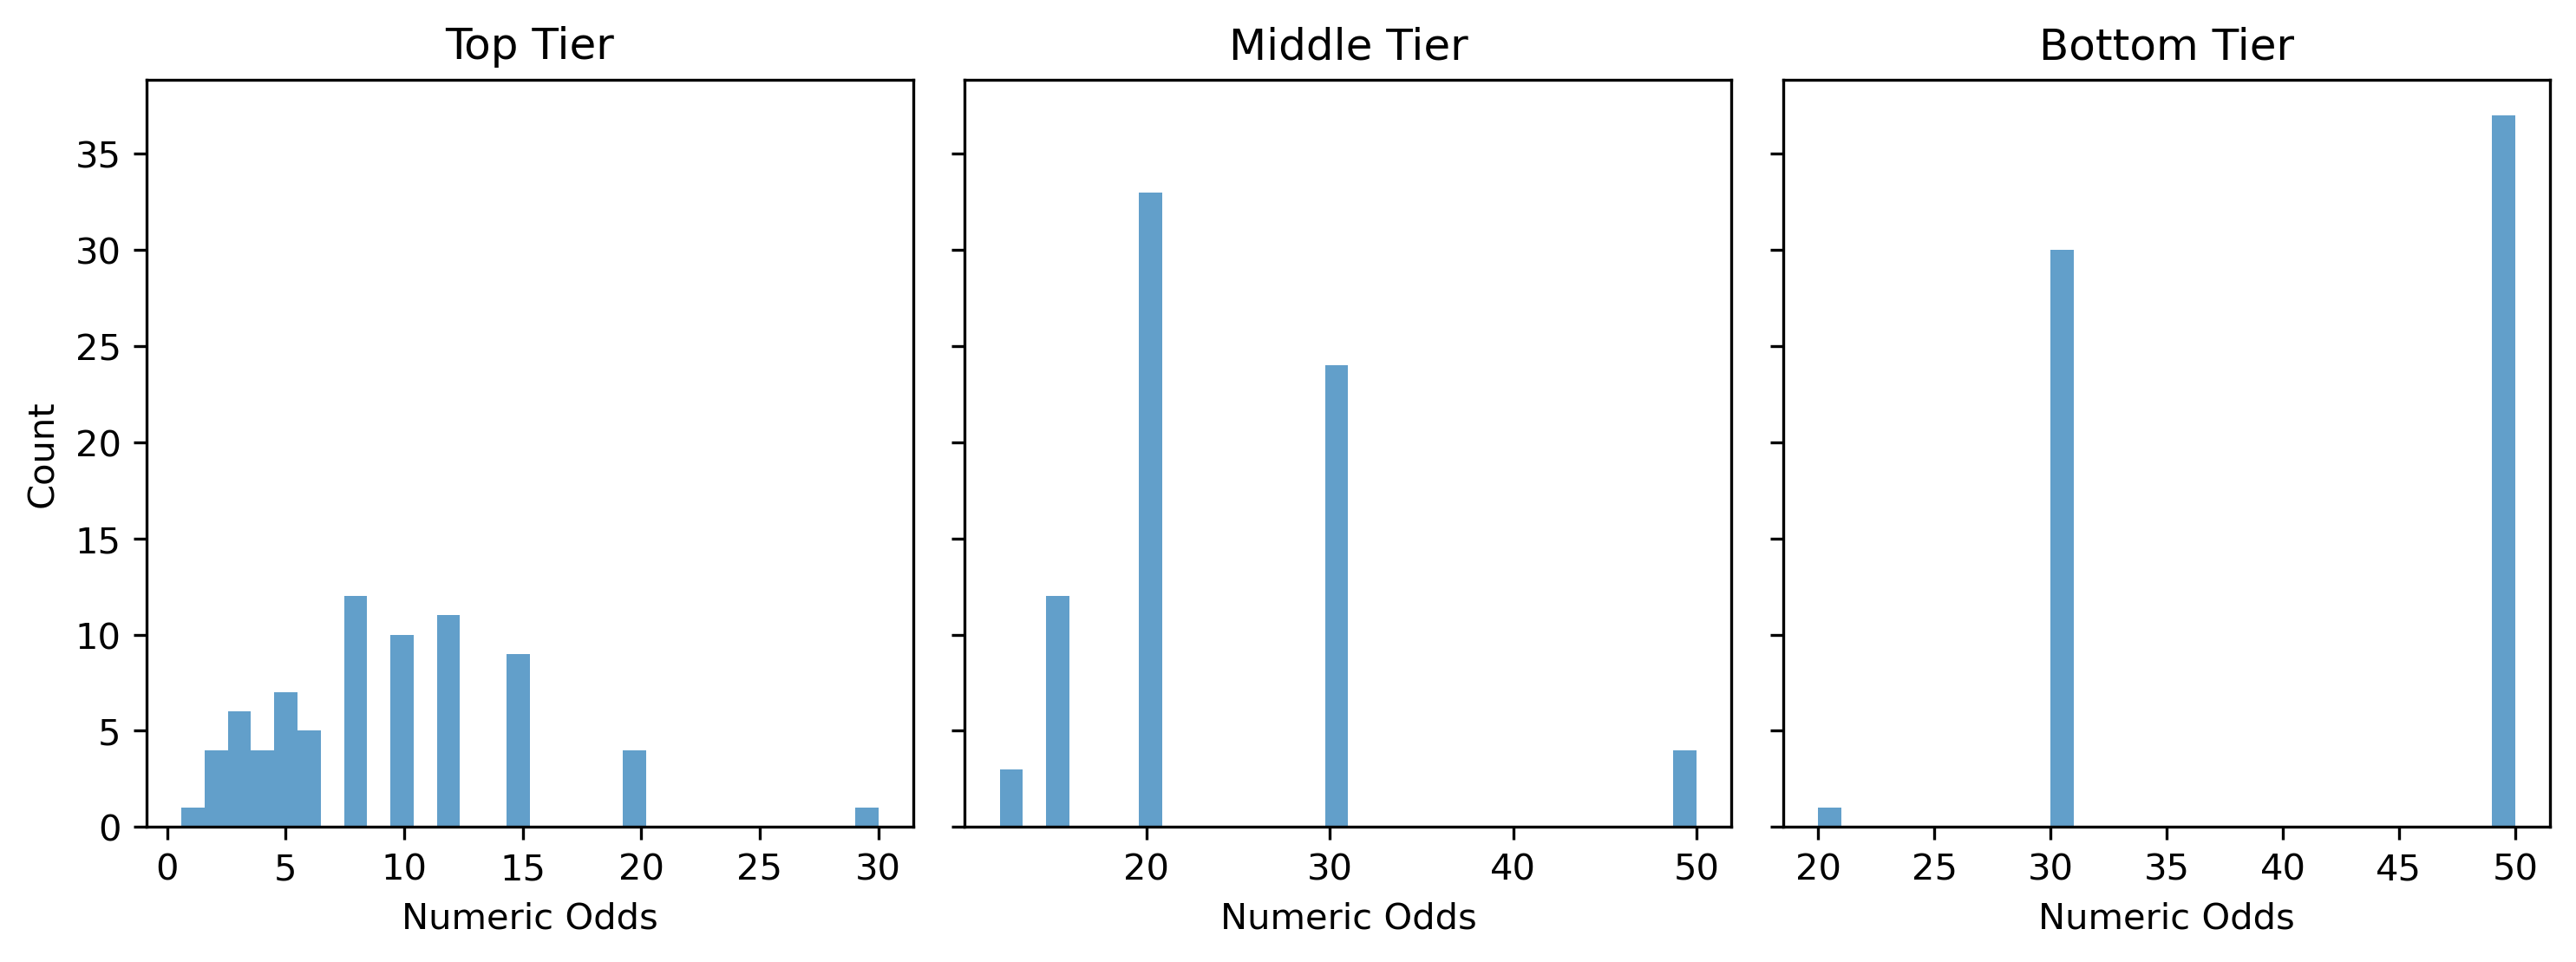

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(10, 4),
    dpi=300,
    sharey=True
)

# Top tier
axes[0].hist(top["MorningLineNumeric"], bins=30, alpha=0.7)
axes[0].set_title("Top Tier")
axes[0].set_xlabel("Numeric Odds")
axes[0].set_ylabel("Count")

# Middle tier
axes[1].hist(middle["MorningLineNumeric"], bins=30, alpha=0.7)
axes[1].set_title("Middle Tier")
axes[1].set_xlabel("Numeric Odds")

# Bottom tier
axes[2].hist(bottom["MorningLineNumeric"], bins=30, alpha=0.7)
axes[2].set_title("Bottom Tier")
axes[2].set_xlabel("Numeric Odds")

# Overall title and layout tweaks
#fig.suptitle("Implied Probability Distributions by Tier", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()



Distribution statistics:
Min odds: 0.60
Max odds: 30.00
Mean odds: 9.24
Median odds: 8.00


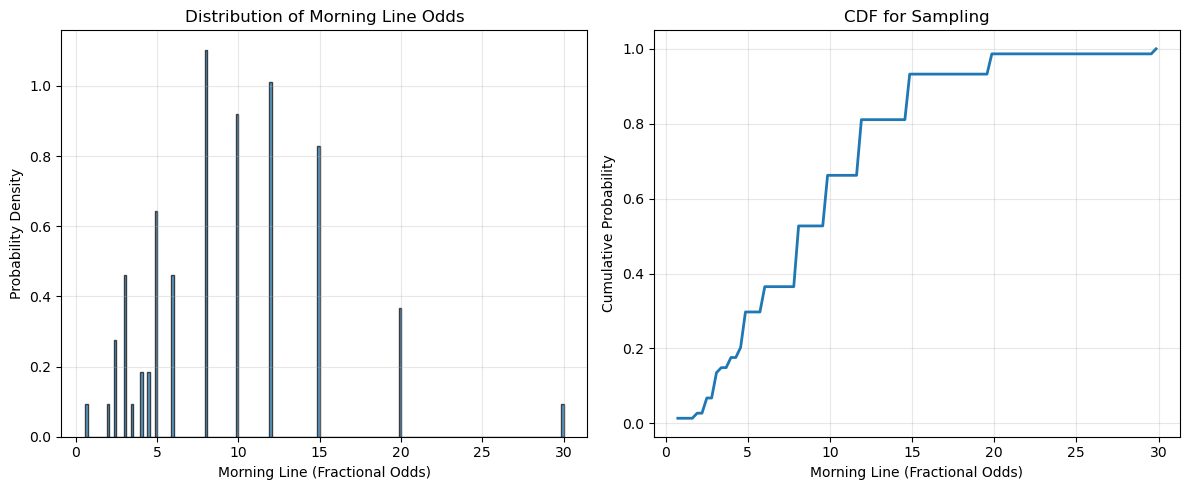


Files created:
- topodds_distribution.json (for JavaScript)
- topbin_centers.txt
- topcdf.txt
- topodds_distribution.png


In [ ]:
import glob
import matplotlib.pyplot as plt
import json
import numpy as np

data = top["MorningLineNumeric"].values
hist, bin_edges = np.histogram(data, bins=100, density=True)

# Create CDF for inverse transform sampling
cdf = np.cumsum(hist * np.diff(bin_edges))
cdf /= cdf[-1]  # Normalize to [0, 1]

# Get bin centers for easier sampling
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Create JavaScript-friendly data structure
js_data = {
    "bin_centers": bin_centers.tolist(),
    "cdf": cdf.tolist(),
    "min_odds": float(data.min()),
    "max_odds": float(data.max()),
    "mean_odds": float(data.mean()),
    "median_odds": float(np.median(data))
}

# Save as JSON for JavaScript
with open("topodds_distribution.json", "w") as f:
    json.dump(js_data, f, indent=2)

print("\nDistribution statistics:")
print(f"Min odds: {js_data['min_odds']:.2f}")
print(f"Max odds: {js_data['max_odds']:.2f}")
print(f"Mean odds: {js_data['mean_odds']:.2f}")
print(f"Median odds: {js_data['median_odds']:.2f}")

# Also save raw data for reference
np.savetxt("bin_centers.txt", bin_centers)
np.savetxt("cdf.txt", cdf)

# Plot the distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(data, bins=200, density=True, alpha=0.7, edgecolor='black')
plt.xlabel("Morning Line (Fractional Odds)")
plt.ylabel("Probability Density")
plt.title("Distribution of Morning Line Odds")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(bin_centers, cdf, linewidth=2)
plt.xlabel("Morning Line (Fractional Odds)")
plt.ylabel("Cumulative Probability")
plt.title("CDF for Sampling")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("odds_distribution.png", dpi=150)
plt.show()

print("\nFiles created:")
print("- topodds_distribution.json (for JavaScript)")
print("- topbin_centers.txt")
print("- topcdf.txt")
print("- topodds_distribution.png")


Distribution statistics:
Min odds: 12.00
Max odds: 50.00
Mean odds: 23.63
Median odds: 20.00


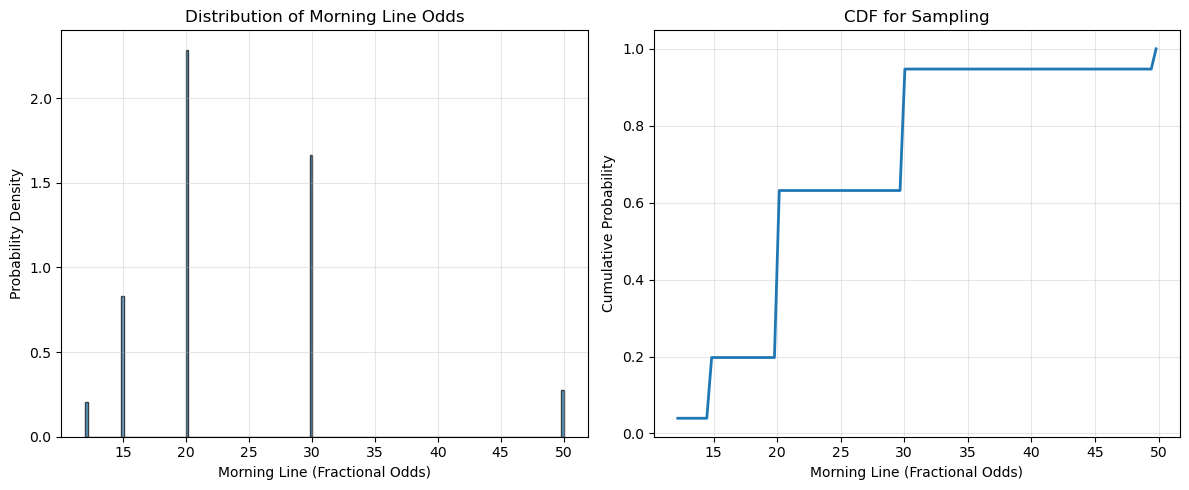


Files created:
- middleodds_distribution.json (for JavaScript)
- middlebin_centers.txt
- middlecdf.txt
- middleodds_distribution.png


In [ ]:
import glob
import matplotlib.pyplot as plt
import json
import numpy as np

data = middle["MorningLineNumeric"].values
hist, bin_edges = np.histogram(data, bins=100, density=True)

# Create CDF for inverse transform sampling
cdf = np.cumsum(hist * np.diff(bin_edges))
cdf /= cdf[-1]  # Normalize to [0, 1]

# Get bin centers for easier sampling
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Create JavaScript-friendly data structure
js_data = {
    "bin_centers": bin_centers.tolist(),
    "cdf": cdf.tolist(),
    "min_odds": float(data.min()),
    "max_odds": float(data.max()),
    "mean_odds": float(data.mean()),
    "median_odds": float(np.median(data))
}

# Save as JSON for JavaScript
with open("middleodds_distribution.json", "w") as f:
    json.dump(js_data, f, indent=2)

print("\nDistribution statistics:")
print(f"Min odds: {js_data['min_odds']:.2f}")
print(f"Max odds: {js_data['max_odds']:.2f}")
print(f"Mean odds: {js_data['mean_odds']:.2f}")
print(f"Median odds: {js_data['median_odds']:.2f}")

# Also save raw data for reference
np.savetxt("bin_centers.txt", bin_centers)
np.savetxt("cdf.txt", cdf)

# Plot the distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(data, bins=200, density=True, alpha=0.7, edgecolor='black')
plt.xlabel("Morning Line (Fractional Odds)")
plt.ylabel("Probability Density")
plt.title("Distribution of Morning Line Odds")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(bin_centers, cdf, linewidth=2)
plt.xlabel("Morning Line (Fractional Odds)")
plt.ylabel("Cumulative Probability")
plt.title("CDF for Sampling")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("odds_distribution.png", dpi=150)
plt.show()

print("\nFiles created:")
print("- middleodds_distribution.json (for JavaScript)")
print("- middlebin_centers.txt")
print("- middlecdf.txt")
print("- middleodds_distribution.png")

Correlation (Morning Line vs. Last Beyer): -0.5516
91.77005347593582
8.968017336254515
47.0
110.0


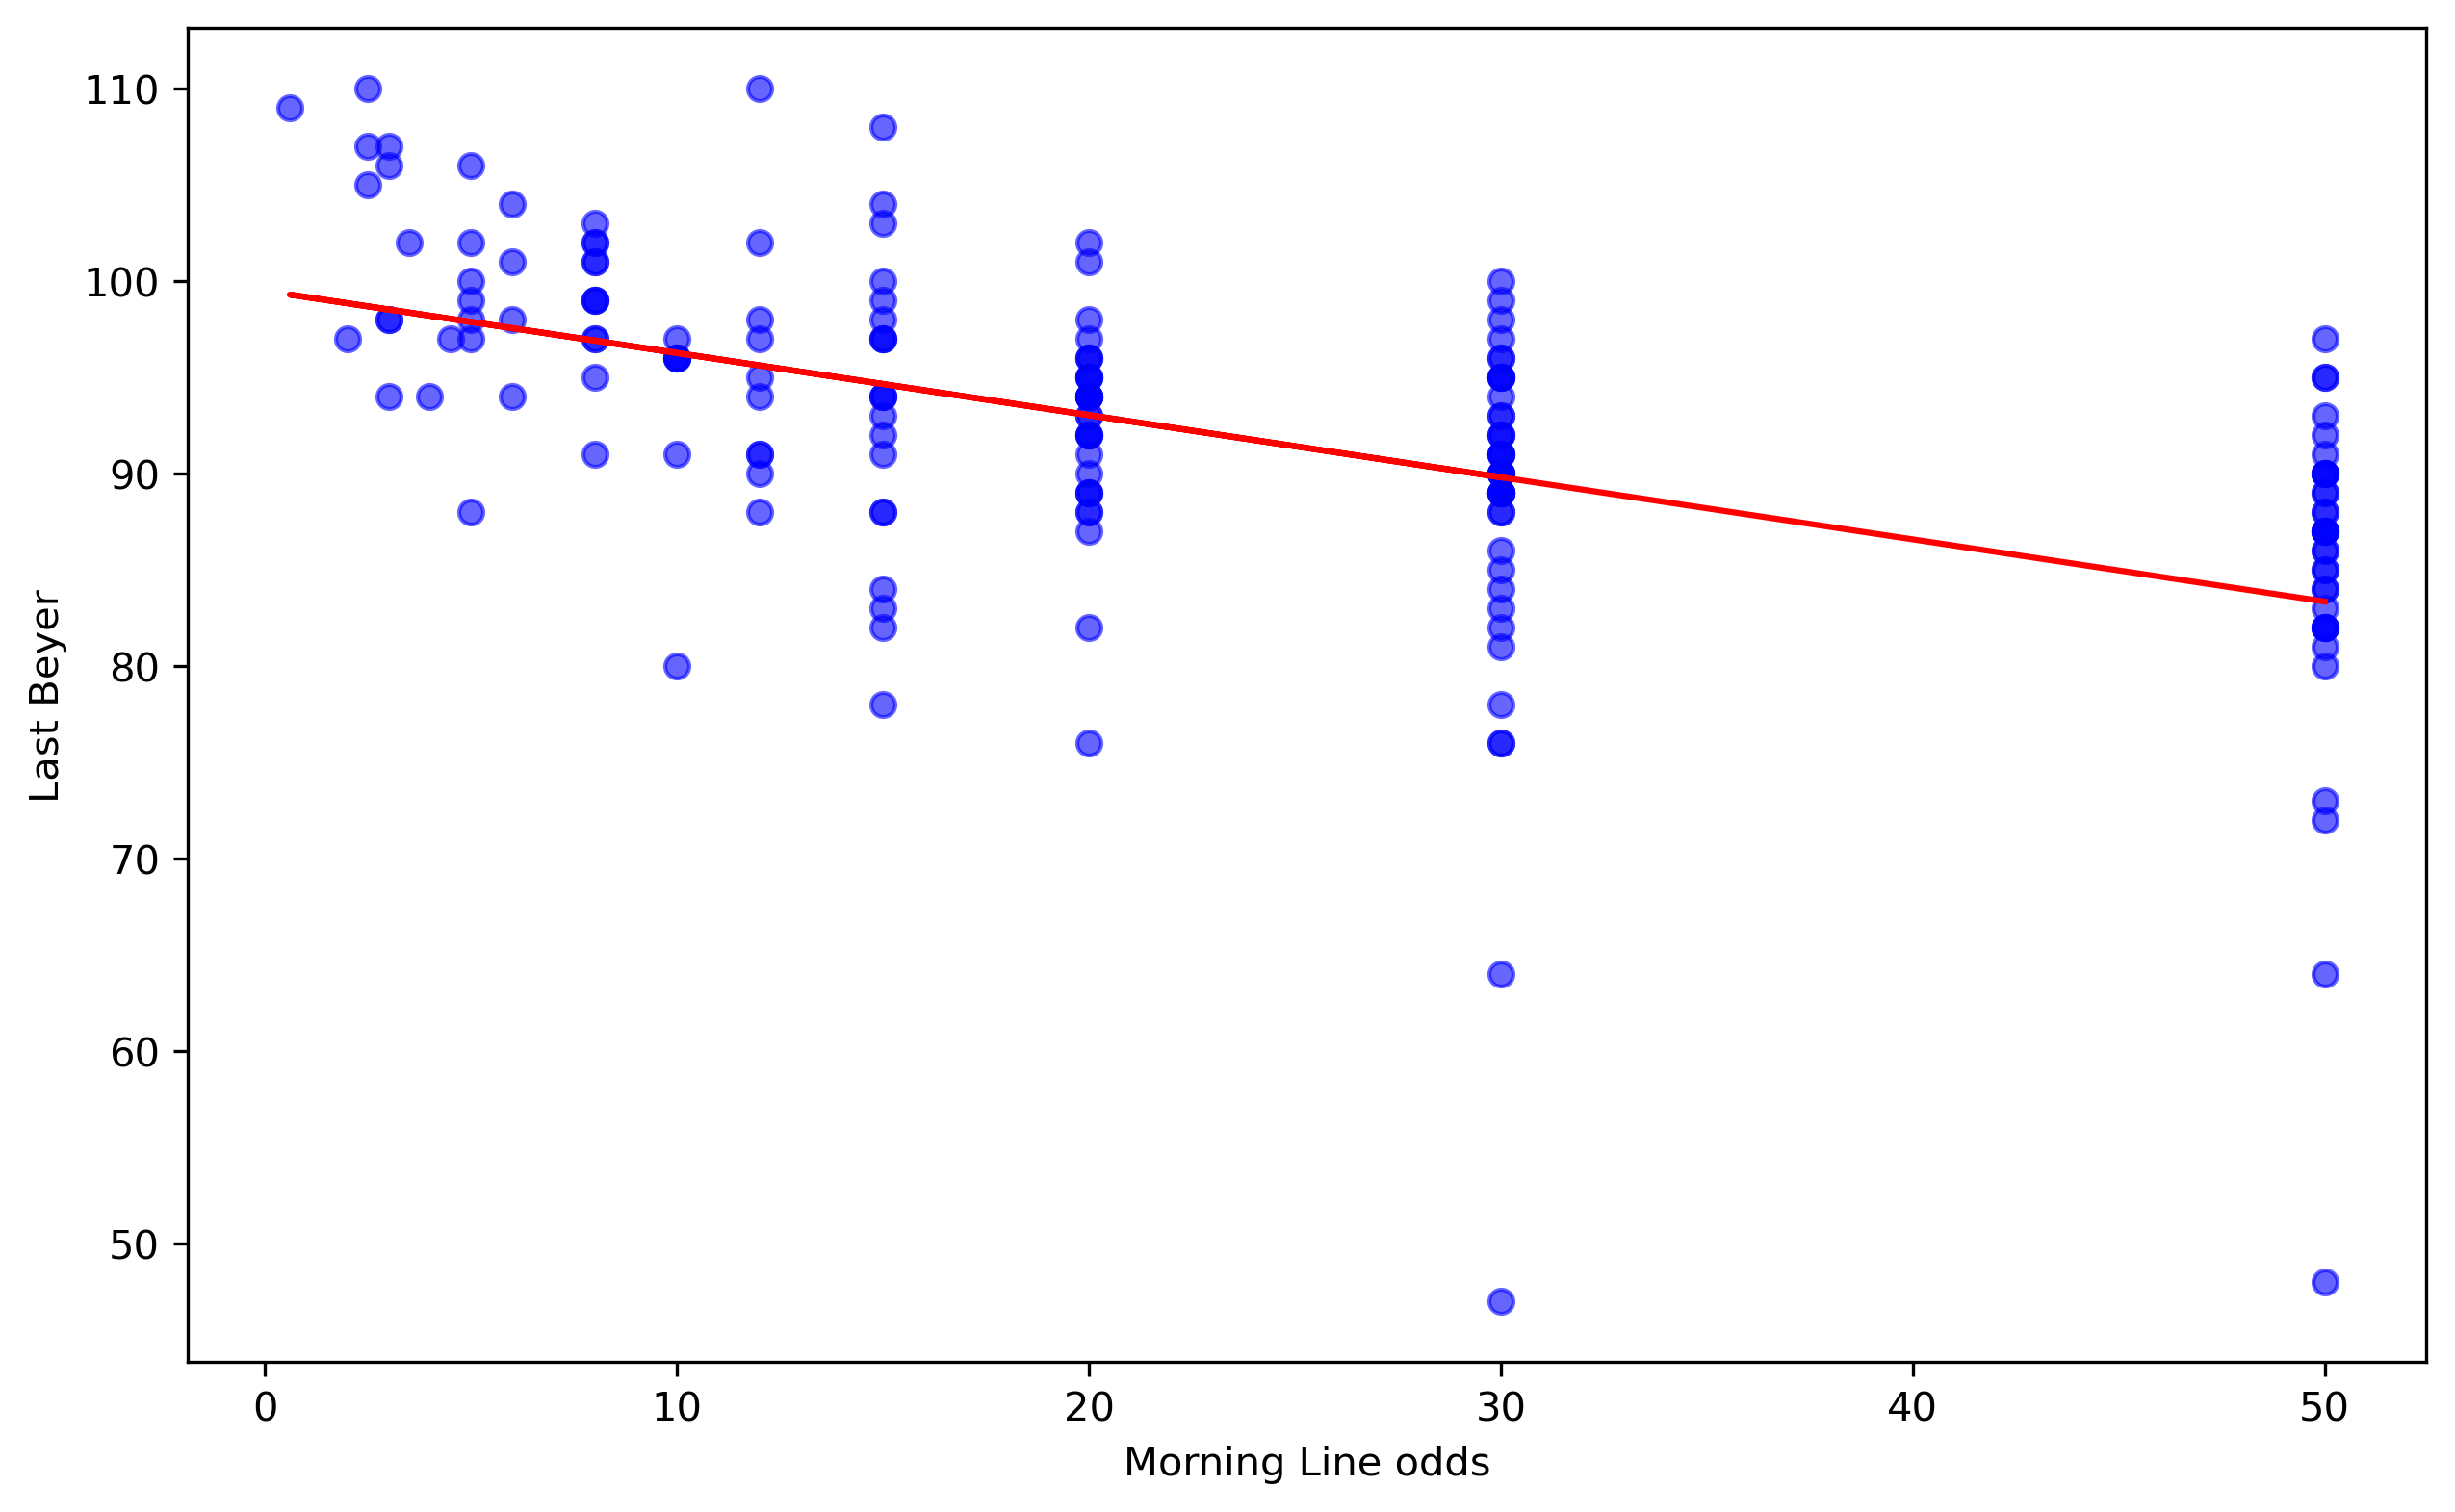

In [ ]:
analysis_cols = ["MorningLineNumeric", "Last Beyer"]
plot_df = df_derby.dropna(subset=analysis_cols).copy()

correlation = plot_df["MorningLineNumeric"].corr(plot_df["Last Beyer"])

plt.figure(figsize=(10, 6), dpi =300)
plt.ylabel("Last Beyer")
plt.xlabel("Morning Line odds") 

m, b = np.polyfit(plot_df["MorningLineNumeric"], plot_df["Last Beyer"], 1)

plt.plot(plot_df["MorningLineNumeric"], m*plot_df["MorningLineNumeric"] + b, color='red', label=f'Best Fit: y={m:.2f}x+{b:.2f}')


plt.scatter(
    plot_df["MorningLineNumeric"], 
    plot_df["Last Beyer"],    
    alpha=0.6,
    color='blue',
)

mean = plot_df["Last Beyer"].mean()
std = plot_df["Last Beyer"].std()
mini = plot_df["Last Beyer"].min()
maxi = plot_df["Last Beyer"].max()


print(f"Correlation (Morning Line vs. Last Beyer): {correlation:.4f}")
print(mean)
print(std)
print(mini)
print(maxi)